# Continuous Plots Examples

This notebook demonstrates the usage of the ContinuousPlots class methods with simple sklearn datasets.

In [1]:
import pandas as pd
from sklearn.datasets import load_iris, load_diabetes
from kvbiii_plots.eda import ContinuousPlots

/home/kvbiii/Desktop/KubiK/Programming/Python/Paczki/kvbiii-plots/kvbiii-plots_venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cont_plots = ContinuousPlots()

iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df["species"] = iris.target_names[iris.target]
iris_df["target"] = iris.target

diabetes = load_diabetes()
diabetes_df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
diabetes_df["target"] = diabetes.target

print("Iris dataset shape:", iris_df.shape)
print("Diabetes dataset shape:", diabetes_df.shape)

Iris dataset shape: (150, 6)
Diabetes dataset shape: (442, 11)


## 1. scatter_plot() - Basic Scatter Plot with Hue

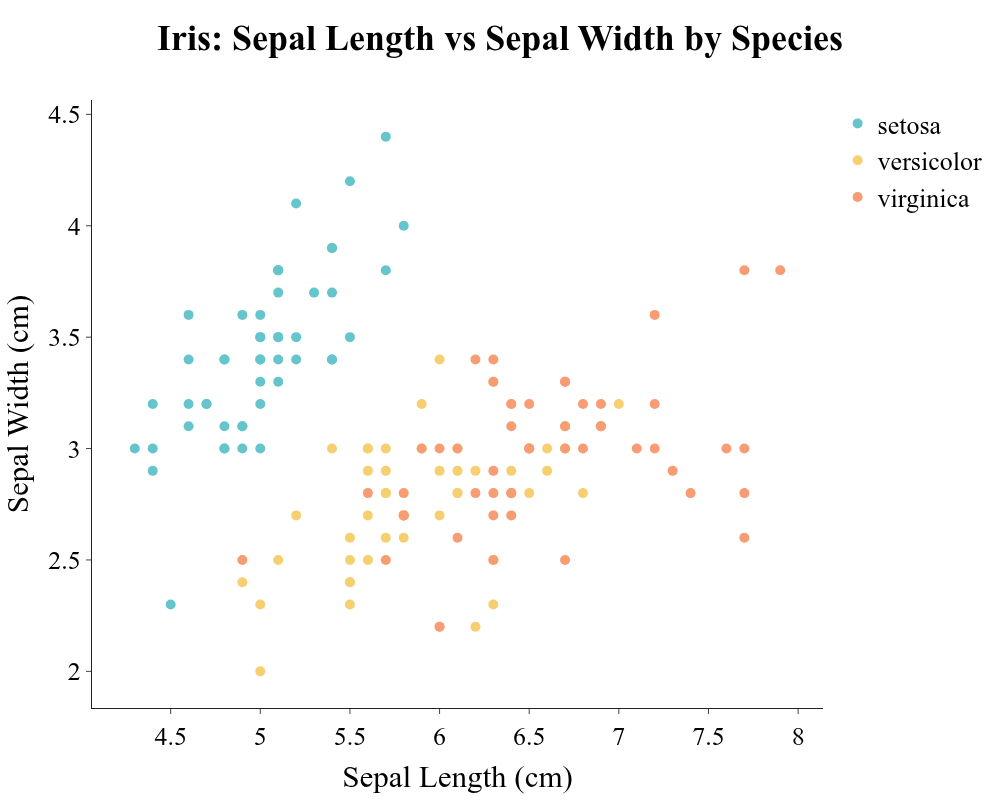

In [3]:
scatter_data = iris_df[["sepal length (cm)", "sepal width (cm)"]].values

cont_plots.scatter_plot(
    data=scatter_data,
    hue=iris_df["species"],
    plot_title="Iris: Sepal Length vs Sepal Width by Species",
    width=1000,
    height=800,
    xaxis_title="Sepal Length (cm)",
    yaxis_title="Sepal Width (cm)",
    marker_size=10,
    show_legend=True,
)

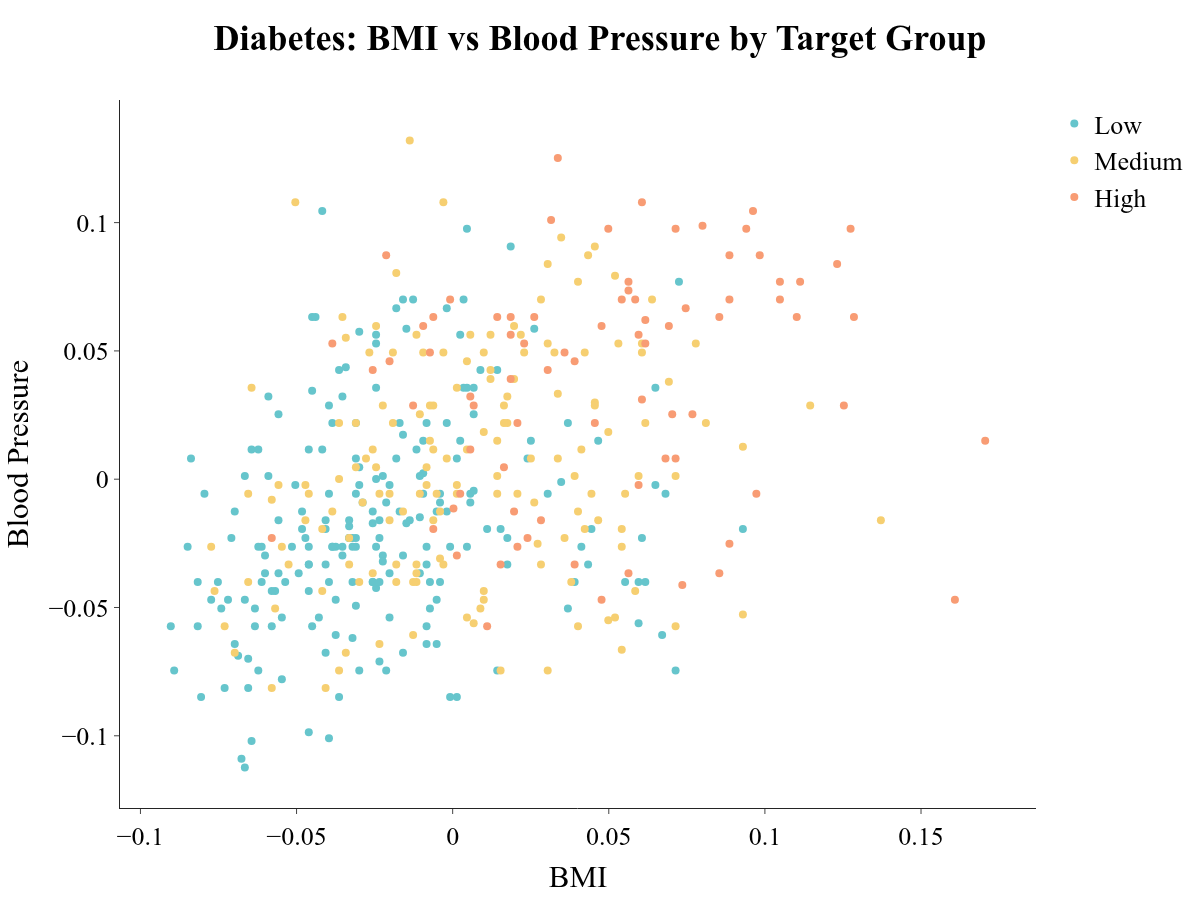

In [4]:
diabetes_scatter_data = diabetes_df[["bmi", "bp"]].values
diabetes_scatter = diabetes_df.copy()
diabetes_scatter["target_group"] = pd.cut(
    diabetes_df["target"], bins=3, labels=["Low", "Medium", "High"]
)

cont_plots.scatter_plot(
    data=diabetes_scatter_data,
    hue=diabetes_scatter["target_group"],
    plot_title="Diabetes: BMI vs Blood Pressure by Target Group",
    width=1200,
    height=900,
    xaxis_title="BMI",
    yaxis_title="Blood Pressure",
    marker_size=8,
    show_legend=True,
)

## 2. histogram_and_box_plot() - Combined Histogram and Box Plot

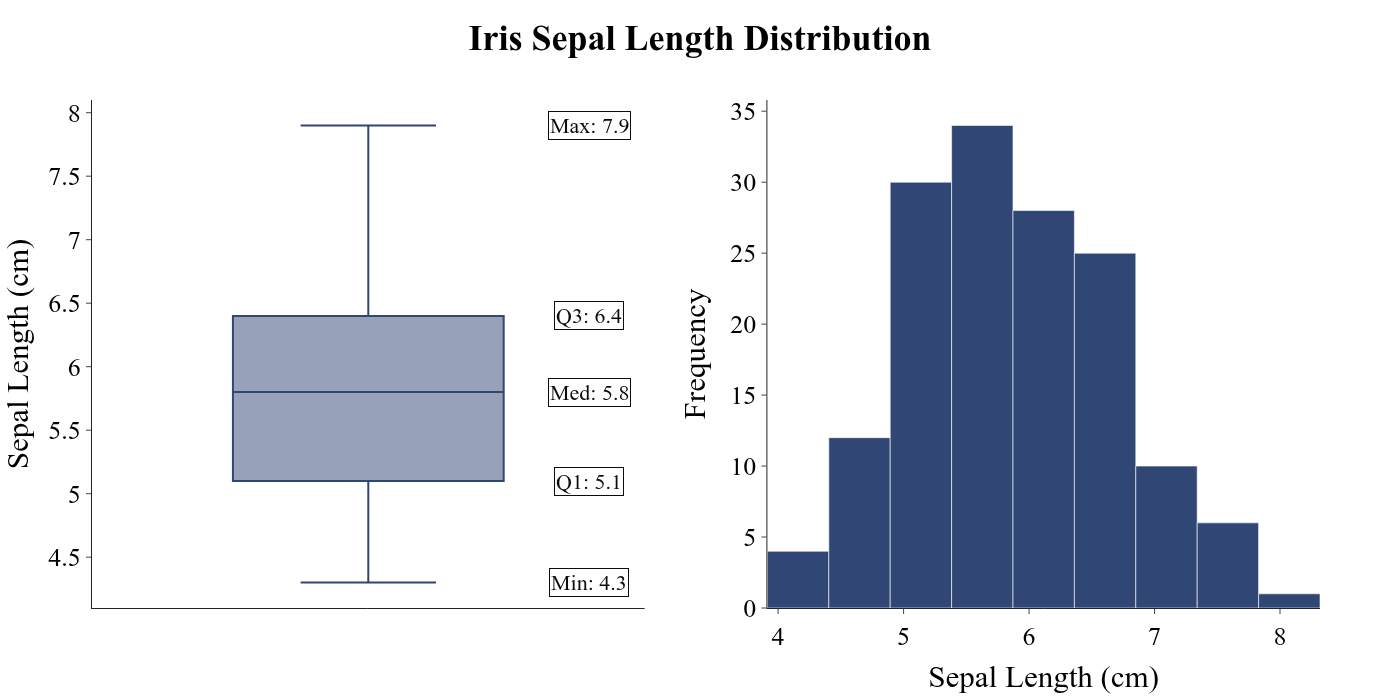

In [5]:
sepal_length_data = iris_df["sepal length (cm)"]

cont_plots.histogram_and_box_plot(
    data=sepal_length_data,
    plot_title="Iris Sepal Length Distribution",
    width=1400,
    height=700,
    xaxis_title="Sepal Length (cm)",
    yaxis_title="Sepal Length (cm)",
)

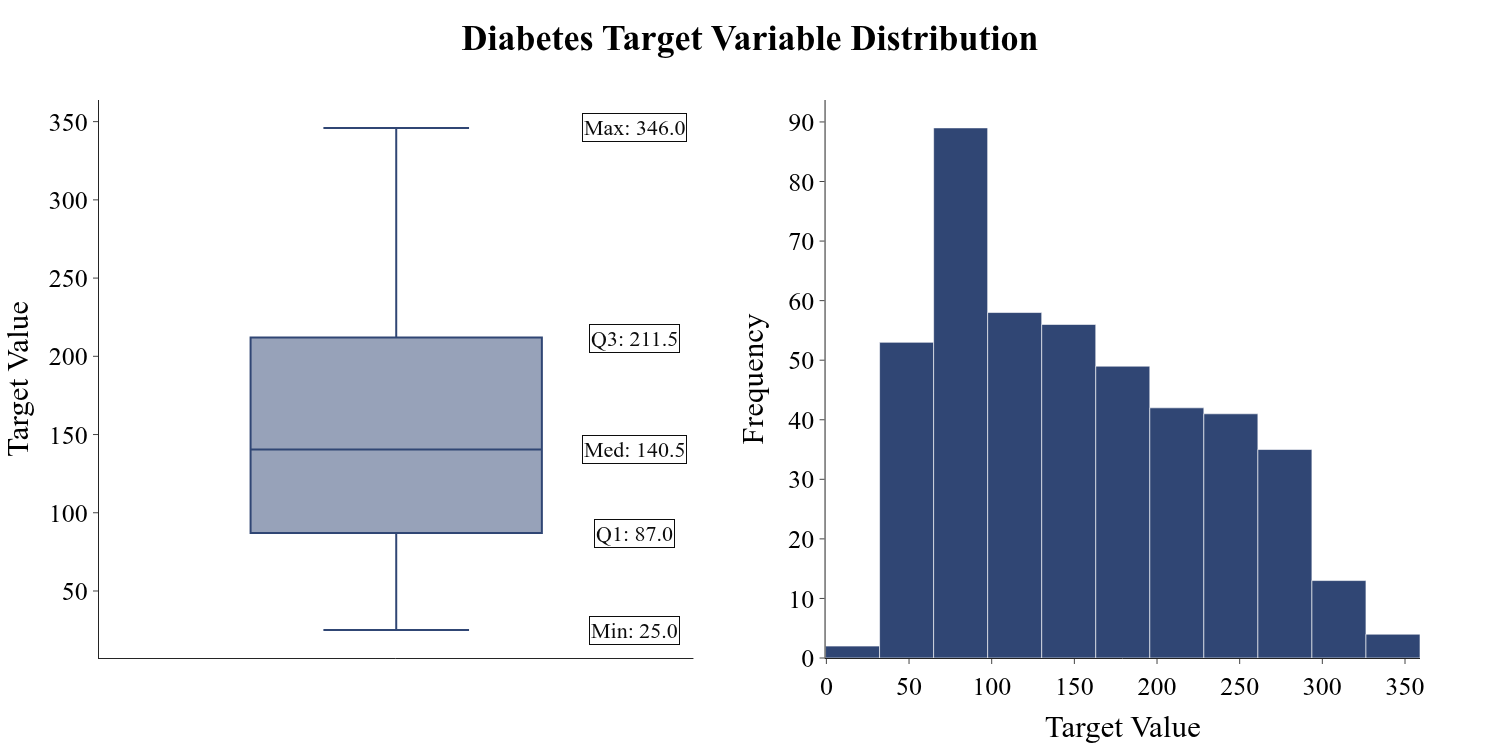

In [6]:
diabetes_target = diabetes_df["target"]

cont_plots.histogram_and_box_plot(
    data=diabetes_target,
    plot_title="Diabetes Target Variable Distribution",
    width=1500,
    height=750,
    xaxis_title="Target Value",
    yaxis_title="Target Value",
)

## 3. histogram_boxplot_linear_regression() - Comprehensive Analysis with Regression

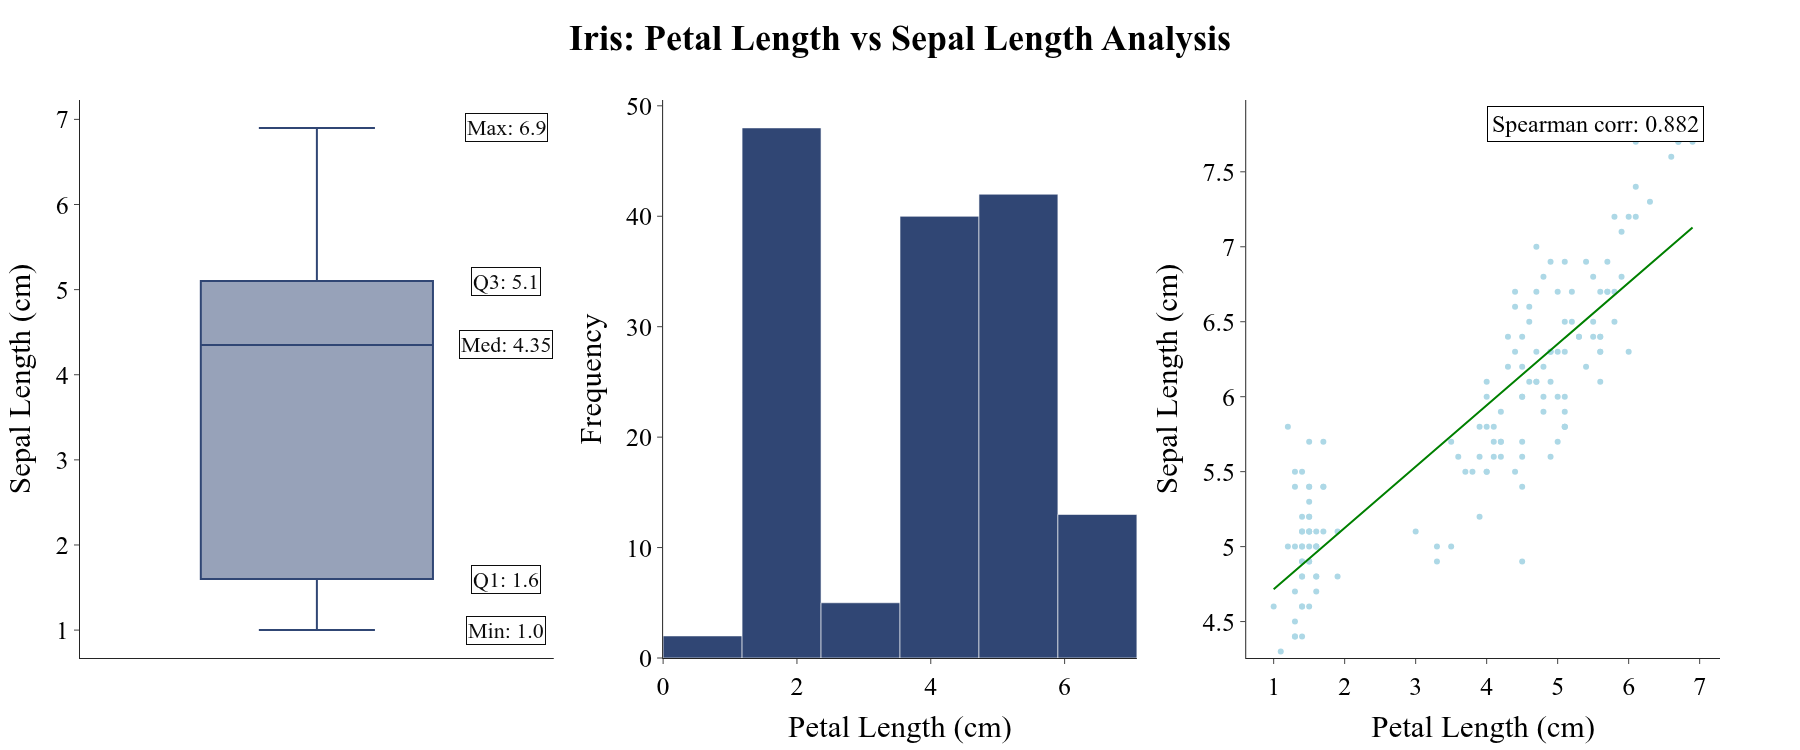

In [7]:
cont_plots.histogram_boxplot_linear_regression(
    data=iris_df,
    feature="petal length (cm)",
    target="sepal length (cm)",
    plot_title="Iris: Petal Length vs Sepal Length Analysis",
    width=1800,
    height=750,
    xaxis_title="Petal Length (cm)",
    yaxis_title="Sepal Length (cm)",
    show_correlation=True,
)

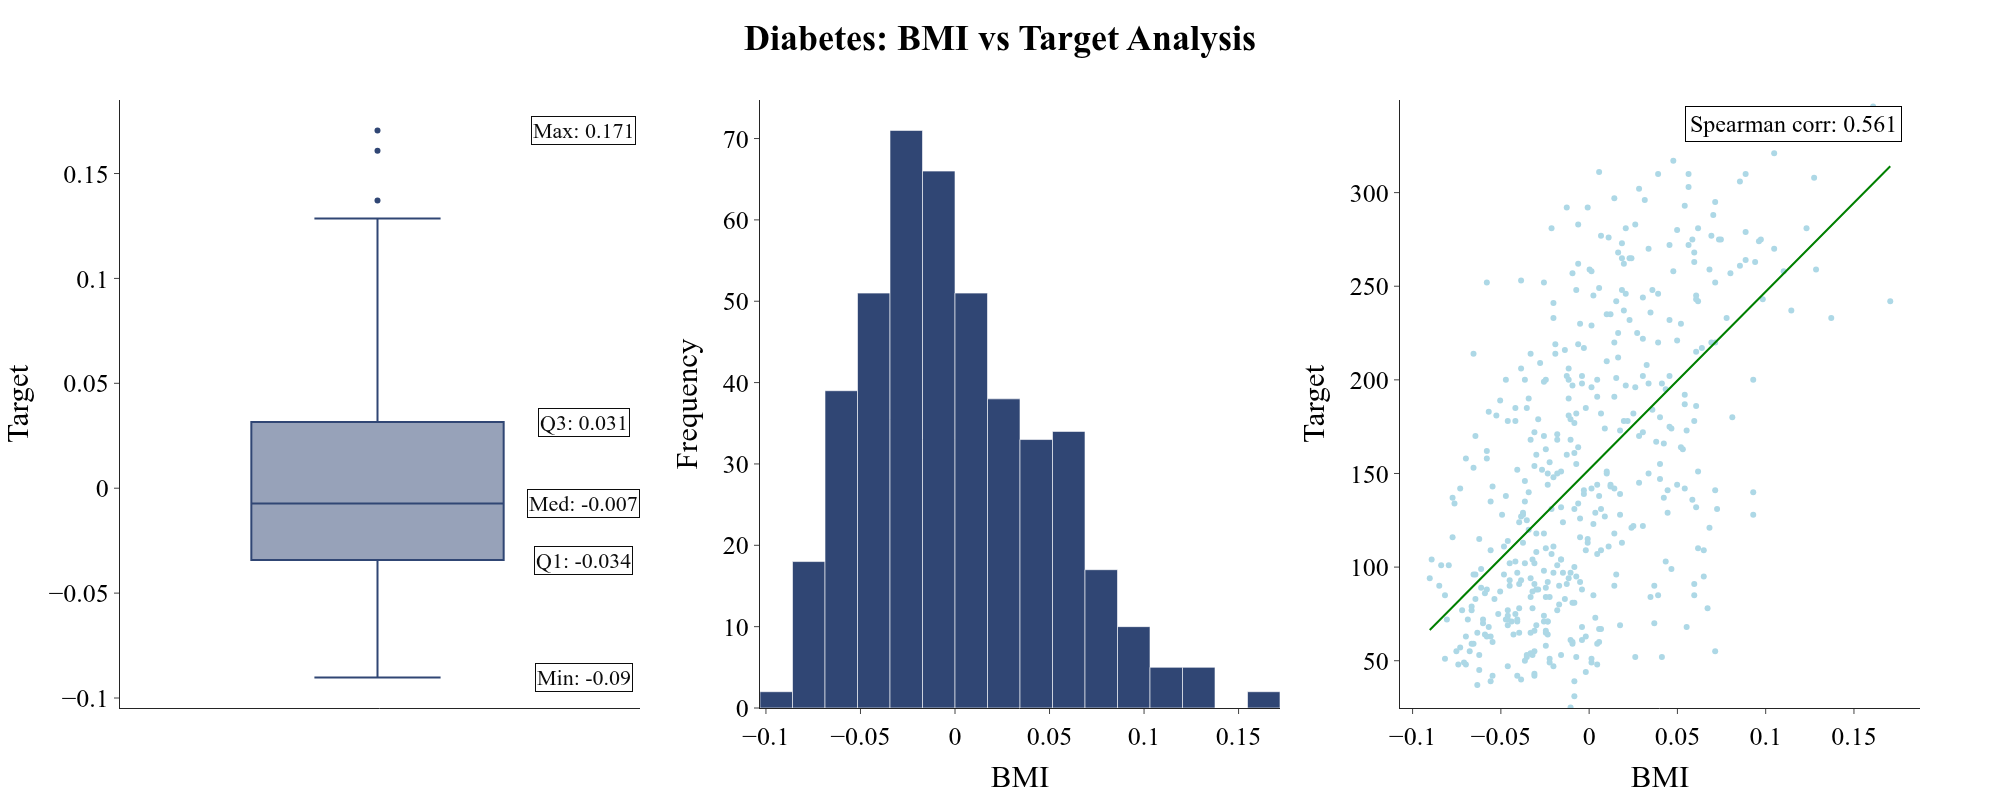

In [8]:
cont_plots.histogram_boxplot_linear_regression(
    data=diabetes_df,
    feature="bmi",
    target="target",
    plot_title="Diabetes: BMI vs Target Analysis",
    width=2000,
    height=800,
    xaxis_title="BMI",
    yaxis_title="Target",
    show_correlation=True,
)

## 4. boxplot_histogram_boxplot_by_hue() - Multi-dimensional Analysis

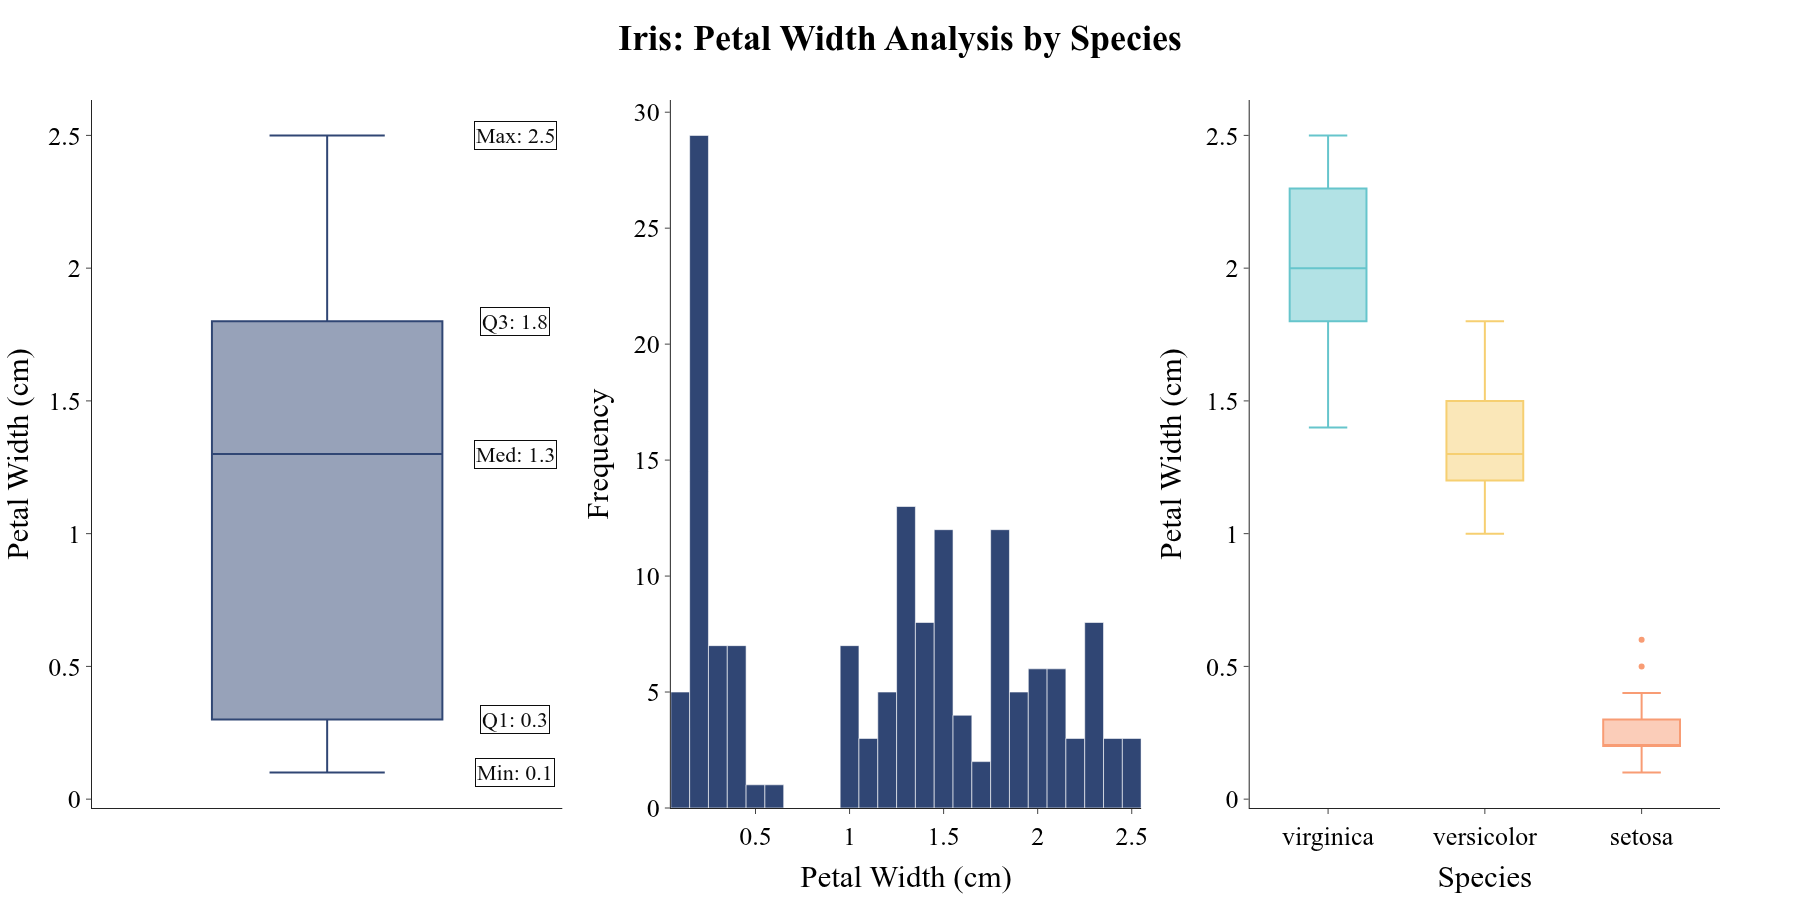

In [9]:
cont_plots.boxplot_histogram_boxplot_by_hue(
    data=iris_df,
    feature="petal width (cm)",
    hue="species",
    plot_title="Iris: Petal Width Analysis by Species",
    annotations=True,
    bin_size=0.1,
    width=1800,
    height=900,
    xaxis_title="Species",
    yaxis_title="Petal Width (cm)",
)

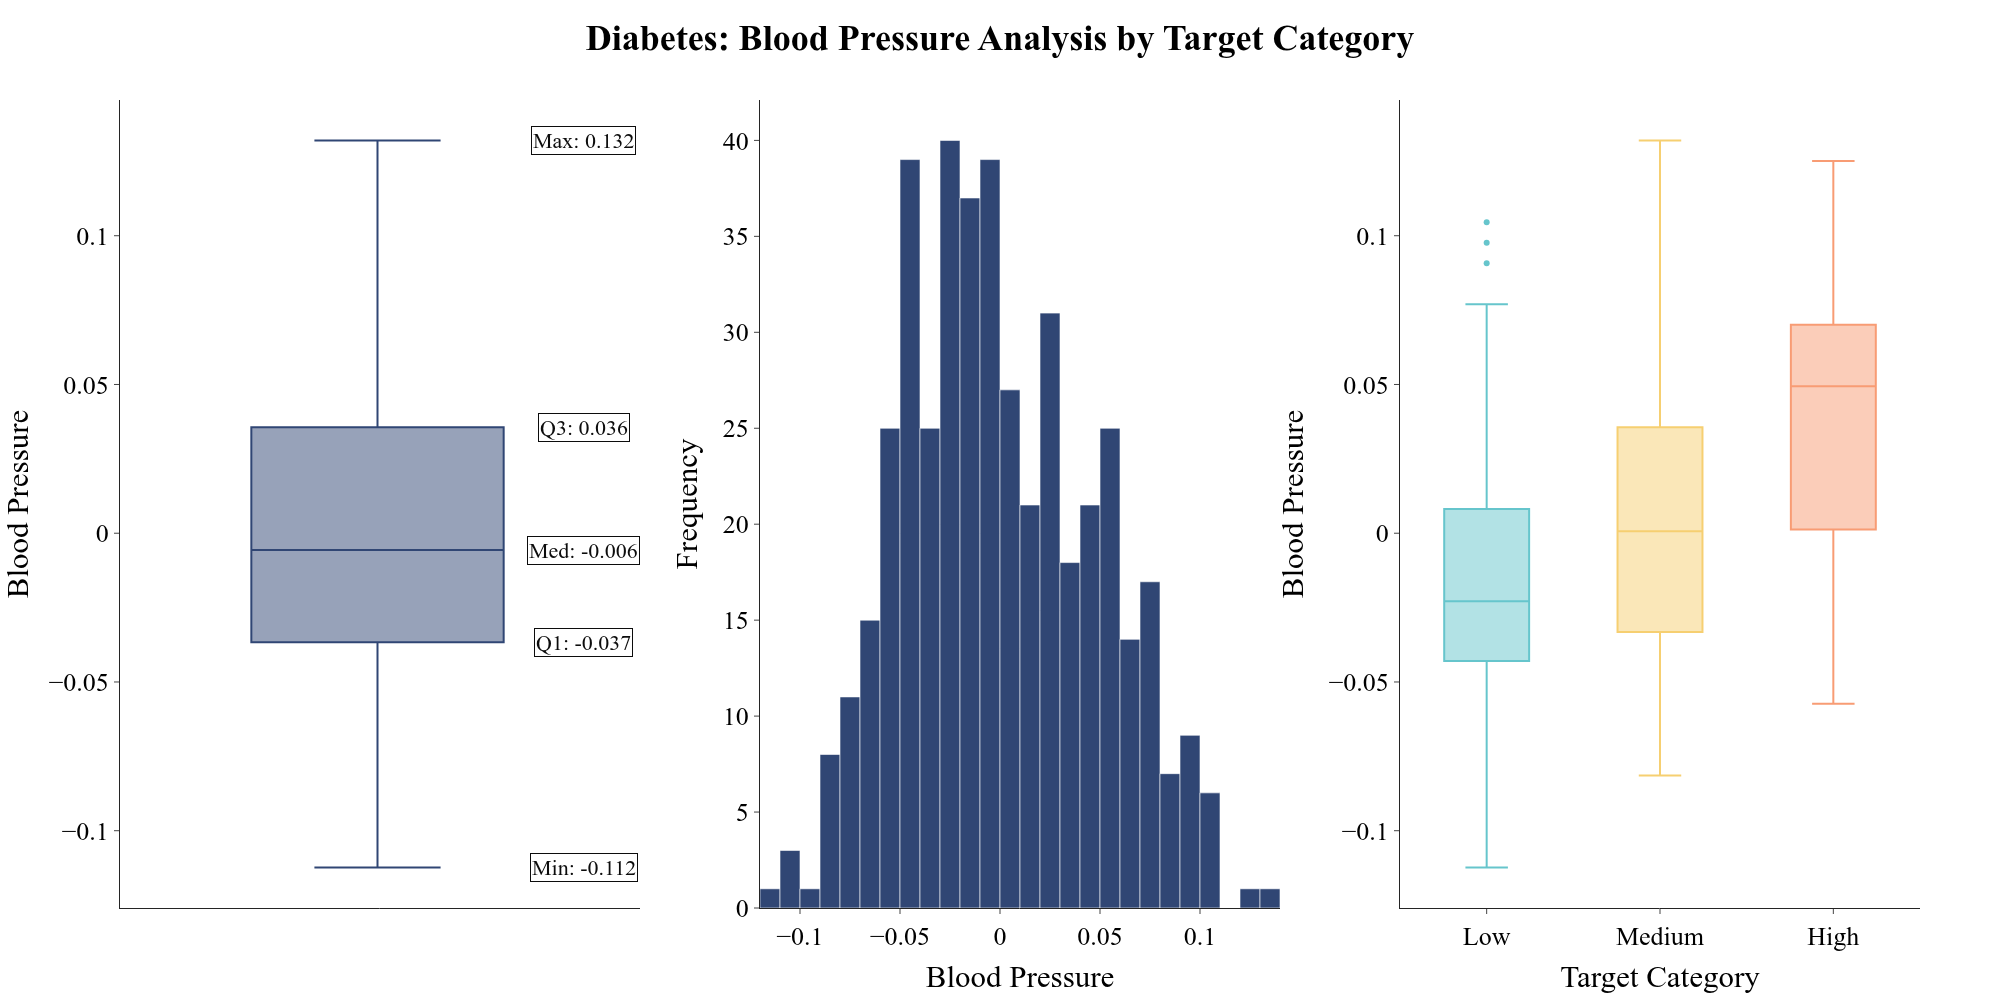

In [10]:
diabetes_with_hue = diabetes_df.copy()
diabetes_with_hue["target_category"] = pd.cut(
    diabetes_df["target"], bins=3, labels=["Low", "Medium", "High"]
)

cont_plots.boxplot_histogram_boxplot_by_hue(
    data=diabetes_with_hue,
    feature="bp",
    hue="target_category",
    plot_title="Diabetes: Blood Pressure Analysis by Target Category",
    annotations=True,
    bin_size=0.01,
    width=2000,
    height=1000,
    xaxis_title="Target Category",
    yaxis_title="Blood Pressure",
)